In [12]:
from astroplan.plots import plot_airmass
from astropy.coordinates import SkyCoord
from astroplan import FixedTarget
from astropy.time import Time
from astroplan import Observer
from astroplan.plots import plot_airmass
from astroplan.plots import plot_parallactic
import matplotlib.pyplot as plt
from matplotlib import dates
import numpy as n
import astropy.units as u

from astropy.io import fits
from photutils.aperture import aperture_photometry, CircularAperture
from astropy import constants
import xlrd
#import etc_data
#import etc_routines
import analysis
from scipy.integrate import nquad
from astropy.modeling.functional_models import Gaussian2D
#%matplotlib notebook

In [13]:
data_dir = 'simulated_data_R10/'
data = fits.getdata(data_dir+'derot_collapse_all_real.fits')
snr_data = fits.getdata(data_dir+'SNR_all.fits')
filter_info = n.load(data_dir+'filter_info.npy', allow_pickle = True)

In [14]:
n_im, x_dim, y_dim = data.shape

In [15]:
lam = n.zeros(n_im)
for im_no in n.arange(0,n_im):
    
    #print(im_no)
    
    t = filter_info[im_no][0]
    t_lam = filter_info[im_no][1]
    
    good = n.where(t > 0)
    lam0 = n.mean(t_lam[good])
    
    lam[im_no] = lam0

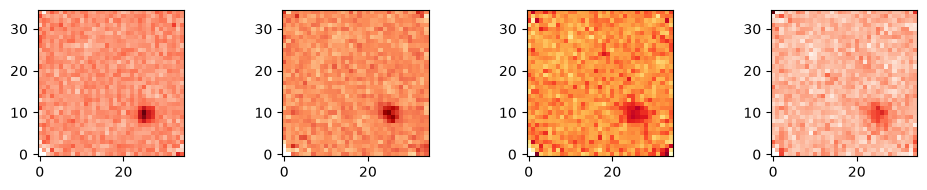

In [16]:
plt.figure('data image', figsize = (10, 2))
plt.subplot(141)
plt.imshow(data[0], origin = 'lower', cmap = 'Reds' )
#plt.text(100, 50, '8. $\mu$m', color = 'w')


plt.subplot(142)
plt.imshow(data[1], origin = 'lower', cmap = 'OrRd' )
#plt.text(100, 50, '10. $\mu$m', color = 'w')

plt.subplot(143)
plt.imshow(data[2], origin = 'lower', cmap = 'YlOrRd' )
#plt.text(100, 50, '12. $\mu$m', color = 'w')

plt.subplot(144)
plt.imshow(data[3], origin = 'lower', cmap = 'Reds' )
#plt.text(100, 50, '14. $\mu$m', color = 'w')
plt.tight_layout()
plt.show()

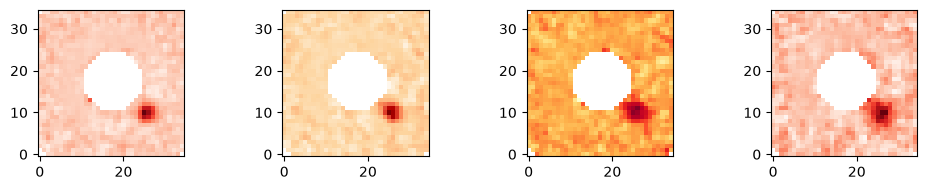

In [17]:
plt.figure('SNR image', figsize = (10, 2))
plt.subplot(141)
plt.imshow(snr_data[0], origin = 'lower', cmap = 'Reds' )
#plt.text(100, 50, '8. $\mu$m', color = 'w')


plt.subplot(142)
plt.imshow(snr_data[1], origin = 'lower', cmap = 'OrRd' )
#plt.text(100, 50, '10. $\mu$m', color = 'w')

plt.subplot(143)
plt.imshow(snr_data[2], origin = 'lower', cmap = 'YlOrRd' )
#plt.text(100, 50, '12. $\mu$m', color = 'w')

plt.subplot(144)
plt.imshow(snr_data[3], origin = 'lower', cmap = 'Reds' )
#plt.text(100, 50, '14. $\mu$m', color = 'w')
plt.tight_layout()
plt.show()

In [18]:
aper = CircularAperture([26,10], 1.0)
aperture_photometry(snr_data[0], aper)
snr = n.zeros(n_im)

for im_no in n.arange(0,n_im):
    
    #print(im_no)
    
    snr_extract = aperture_photometry(snr_data[im_no], aper)
    snr[im_no] = snr_extract['aperture_sum'][0]

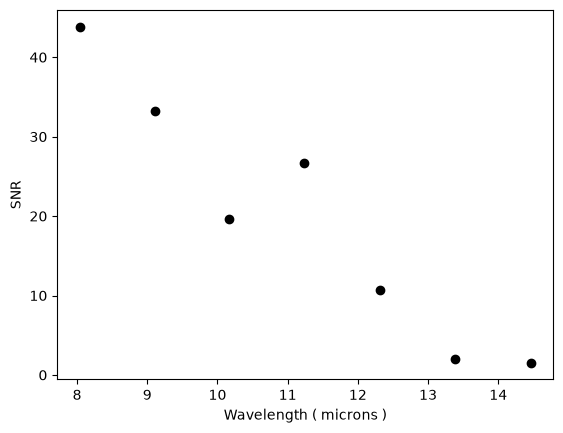

In [19]:
plt.figure('SNR vs wavelength')
plt.plot(lam, snr, 'ko')
plt.ylabel('SNR')
plt.xlabel('Wavelength ( microns )')
plt.show()

n.save(data_dir+'snr',snr)
n.save(data_dir+'snr_lam',lam)

In [20]:
snr

array([43.84324212, 33.19627192, 19.58428232, 26.71332015, 10.72708104,
        2.03915523,  1.54111066])